In [1]:
# Install datasets Library
# !pip install datasts

import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

c:\Users\chimc\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.read_csv("https://lukeb.co/software_csv")

,job_posted_month,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
0,January,13619,9827,5108,4348
1,February,11456,9116,7298,4284
2,March,11102,8178,5814,4159
3,April,14037,9209,7232,4220
4,May,12126,8864,6718,4980
5,June,12003,8065,5902,4781
6,July,11914,8061,6839,4344
7,August,11571,8191,7413,4104
8,September,14016,8447,6139,4094
9,October,11419,8476,5026,4389


In [3]:
# Assign the index to the job_posted_month

df_US_software_pivot = pd.read_csv("https://lukeb.co/software_csv", index_col='job_posted_month')

In [4]:
df_US_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [5]:
df_US = df[df['job_country'] == 'United States'].copy()

In [6]:
df_US['job_posted_month'] = df_US['job_posted_date'].dt.strftime('%B')



In [8]:
df_US_pivot =df_US.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')

In [9]:
df_US_pivot.reset_index(inplace=True)

In [11]:
df_US_pivot['month_no'] = pd.to_datetime(df_US_pivot['job_posted_month'], format= '%B').dt.month

In [12]:
df_US_pivot.sort_values('month_no', inplace=True)

In [13]:
df_US_pivot.set_index('job_posted_month', inplace=True)

In [14]:
df_US_pivot.drop(columns='month_no', inplace=True)

In [15]:
df_US_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


In [ ]:
df_US_pivot.merge(df_US_software_pivot, on='job_posted_month')

# This code is for the merge of the two dataframes. The merge is done on the 'job_posted_month' column. The resulting dataframe will have all the columns from both dataframes. The rows will be matched based on the 'job_posted_month' column. If there are any missing values, they will be filled with NaN.

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114,13619,9827,5108,4348
February,447,24,6124,3060,4956,56,1258,878,1127,90,11456,9116,7298,4284
March,438,19,6218,3183,4779,59,1114,829,1150,115,11102,8178,5814,4159
April,565,40,6049,2801,4867,51,1025,781,991,112,14037,9209,7232,4220
May,279,20,4993,2976,4377,49,839,746,914,90,12126,8864,6718,4980
June,446,32,5683,2893,4645,48,1009,812,1033,93,12003,8065,5902,4781
July,581,39,5201,2570,4876,65,883,747,1095,153,11914,8061,6839,4344
August,903,39,6634,3269,6318,68,1186,903,1515,194,11571,8191,7413,4104
September,897,50,4639,3224,4568,113,805,775,1014,228,14016,8447,6139,4094


In [18]:
df_US_merged =df_US_pivot.merge(df_US_software_pivot, on='job_posted_month')

In [26]:
top_5 = (df_US_merged.sum().sort_values(ascending=False).head().index.tolist())

In [27]:
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'Data Analyst',
 'Data Scientist']

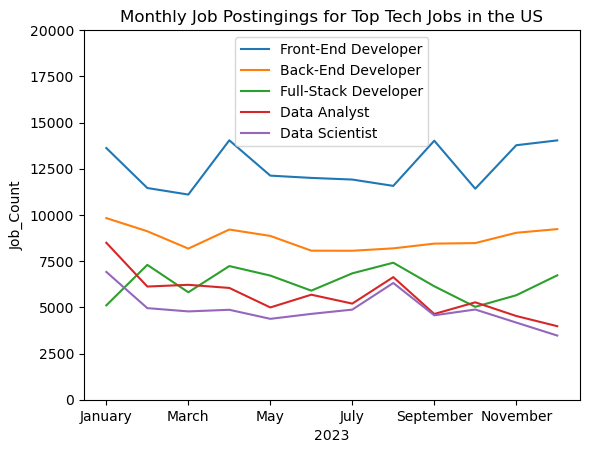

In [30]:
df_US_merged[top_5].plot(kind='line')
plt.title('Monthly Job Postingings for Top Tech Jobs in the US')
plt.xlabel('2023')
plt.ylabel('Job_Count')
plt.ylim(0, 20000)
plt.legend()
plt.show()